In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
matplotlib.rcParams["ps.useafm"] = True
matplotlib.rcParams["pdf.use14corefonts"] = True
import seaborn as sns
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
%matplotlib inline
import pandas as pd
plt.rcParams['font.size'] = 8

In [2]:
df = pd.read_csv('/rawdata/fig3_rawdata.csv')
df.columns=['causal', 'positive', 'A', 'B', 'C', 'D', 'E', 'F']
df = df[['causal', 'positive', 'D', 'C']]
df = df.loc[df['positive']>=0.5]
df.columns=['Causal proportion', 'Effect direction mixture', 'Unmodified', 'PrediXSKAT',]
noefp = df.melt(id_vars=['Causal proportion', 'Effect direction mixture'], var_name='kernel', value_name='pval')

In [3]:
def power(x, alpha):
    pvals = x['pval']
    type2_error = len([x for x in pvals if (x) > alpha]) / len(pvals)
    power = 1 - type2_error
    return power

In [4]:
noef_power1 = noefp.groupby(['Causal proportion', 'Effect direction mixture', 'kernel']).apply(power, alpha=0.05).reset_index()
noef_power2 = noefp.groupby(['Causal proportion', 'Effect direction mixture', 'kernel']).apply(power, alpha=0.0005).reset_index()

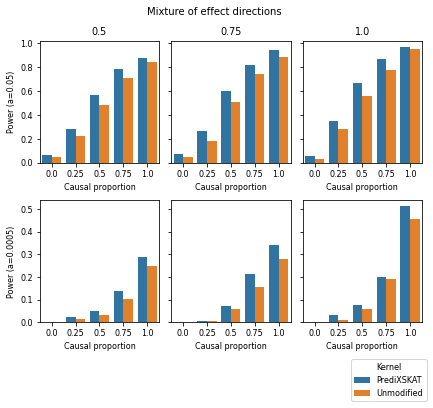

In [5]:
dataframes = [noef_power1, noef_power2]
col_vals = noef_power1['Effect direction mixture'].unique() 
n_rows, n_cols = len(dataframes), len(col_vals)
row_labels = ['Power (a=0.05)', 'Power (a=0.0005)'] 
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6, 5),
    sharey='row')

for row, df in enumerate(dataframes):
    for col, col_val in enumerate(col_vals):
        ax = axes[row, col]
        subset = df[df['Effect direction mixture'] == col_val]
        sns.barplot(data=subset, x='Causal proportion', y=0, hue='kernel', ax=ax)
        if row == 0:
            ax.set_title(col_val)
        ax.set_ylabel(row_labels[row] if col == 0 else '')
        ax.get_legend().remove()

fig.suptitle('Mixture of effect directions', fontsize=10)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Kernel', loc='lower right', bbox_to_anchor=(1, -0.125))

plt.tight_layout()
fig.savefig("fig3.pdf", format="pdf", bbox_inches="tight");

In [37]:
df = pd.read_csv('/rawdata/fig3_rawdata.csv')
df.columns=['causal', 'positive', 'A', 'B', 'C', 'D', 'E', 'F']
df = df[['causal', 'positive', 'D', 'C']]
df.columns=['Causal proportion', 'Effect direction mixture', 'Unmodified', 'PrediXSKAT',]
noefp = df.melt(id_vars=['Causal proportion', 'Effect direction mixture'], var_name='kernel', value_name='pval')

In [41]:
type1=noefp.loc[noefp['Causal proportion']==0][['kernel', 'pval']]

In [50]:
thresholds = [1e0, 1e-1, 1e-2, 1e-3,1e-4,1e-5, 0.5, 0.05, 0.005, 0.0005, 0.00005, 0.000005]
thresholds.sort()
unmod_counts = [(type1.loc[type1['kernel']=='Unmodified']['pval'] <= t).sum() for t in thresholds]
skat_counts = [(type1.loc[type1['kernel']=='PrediXSKAT']['pval'] <= t).sum() for t in thresholds]

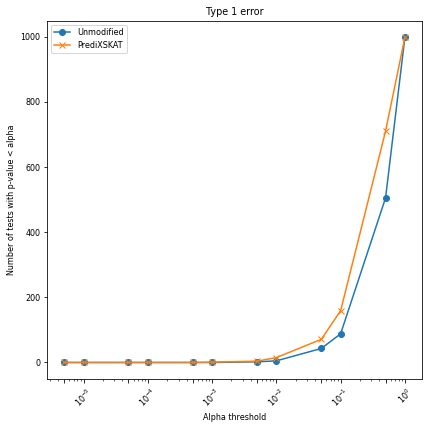

In [56]:
fig, ax = plt.subplots(figsize=(6,6))

ax.plot(thresholds, unmod_counts, marker='o', linewidth=1.5, markersize=6, label='Unmodified')
ax.plot(thresholds, skat_counts, marker='x', linewidth=1.5, markersize=6, label='PrediXSKAT')

ax.set_xscale('log')
ax.set_xticks(thresholds)
ax.tick_params(axis='x', rotation=45)

ax.set_xlabel('Alpha threshold')
ax.set_ylabel('Number of tests with p-value < alpha')
ax.set_title('Type 1 error')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()
fig.savefig("figs3.pdf", format="pdf", bbox_inches="tight");

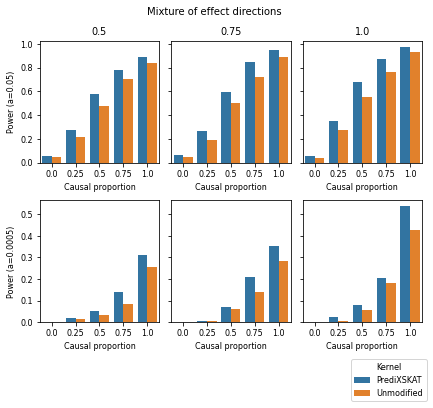

In [29]:
df = pd.read_csv('/rawdata/fig3_rawdata.csv')
df.columns=['Causal proportion', 'Effect direction mixture', 'A', 'B', 'C', 'D', 'E', 'F']
df = df[['Causal proportion', 'Effect direction mixture', 'A', 'F']]
df = df.loc[df['Effect direction mixture']>=0.5]
df.columns=['Causal proportion', 'Effect direction mixture', 'Unmodified', 'PrediXSKAT',]
noefp = df.melt(id_vars=['Causal proportion', 'Effect direction mixture'], var_name='kernel', value_name='pval')

noef_power1 = noefp.groupby(['Causal proportion', 'Effect direction mixture', 'kernel']).apply(power, alpha=0.05).reset_index()
noef_power2 = noefp.groupby(['Causal proportion', 'Effect direction mixture', 'kernel']).apply(power, alpha=0.0005).reset_index()

dataframes = [noef_power1, noef_power2]
col_vals = noef_power1['Effect direction mixture'].unique() 
n_rows, n_cols = len(dataframes), len(col_vals)
row_labels = ['Power (a=0.05)', 'Power (a=0.0005)'] 
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6, 5),
    sharey='row')

for row, df in enumerate(dataframes):
    for col, col_val in enumerate(col_vals):
        ax = axes[row, col]
        subset = df[df['Effect direction mixture'] == col_val]
        sns.barplot(data=subset, x='Causal proportion', y=0, hue='kernel', ax=ax)
        if row == 0:
            ax.set_title(col_val)
        ax.set_ylabel(row_labels[row] if col == 0 else '')
        ax.get_legend().remove()

fig.suptitle('Mixture of effect directions', fontsize=10)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Kernel', loc='lower right', bbox_to_anchor=(1, -0.125))

plt.tight_layout();
fig.savefig("fig4.pdf", format="pdf", bbox_inches="tight");

<AxesSubplot:xlabel='Causal proportion', ylabel='0'>

Text(0.5, 1.0, '0.5')

Text(0, 0.5, 'Power (a=0.05)')

<AxesSubplot:xlabel='Causal proportion', ylabel='0'>

Text(0.5, 1.0, '0.75')

...

Text(0, 0.5, '')

<AxesSubplot:xlabel='Causal proportion', ylabel='0'>

Text(0, 0.5, '')

Text(0.5, 0.98, 'Mixture of effect directions')

''

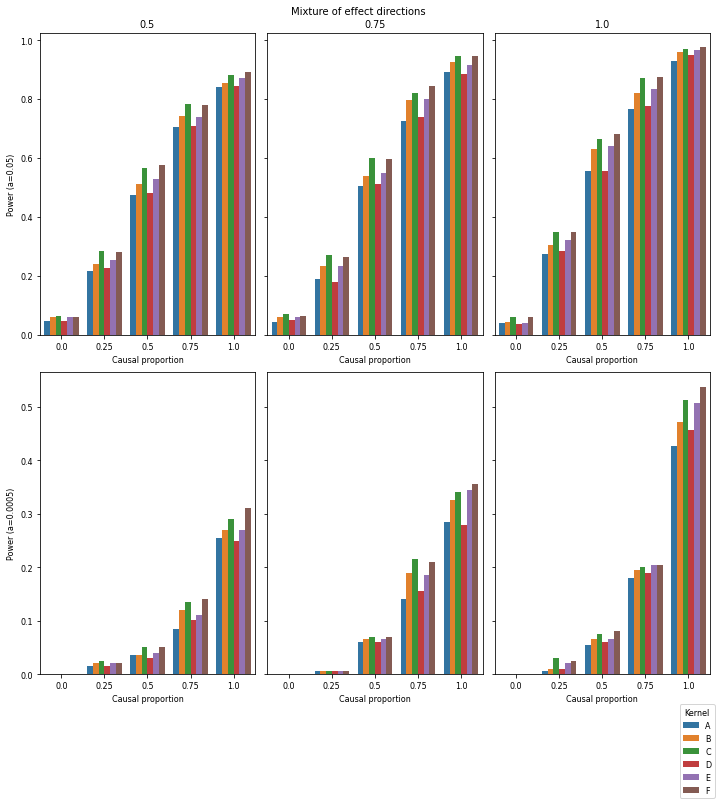

In [20]:
df = pd.read_csv('/rawdata/fig3_rawdata.csv')
df.columns=['Causal proportion', 'Effect direction mixture', 'A', 'B', 'C', 'D', 'E', 'F']
#df = df[['Causal proportion', 'Effect direction mixture', 'A', 'F']]
df = df.loc[df['Effect direction mixture']>=0.5]
#df.columns=['Causal proportion', 'Effect direction mixture', 'Unmodified', 'PrediXSKAT',]
noefp = df.melt(id_vars=['Causal proportion', 'Effect direction mixture'], var_name='kernel', value_name='pval')

noef_power1 = noefp.groupby(['Causal proportion', 'Effect direction mixture', 'kernel']).apply(power, alpha=0.05).reset_index()
noef_power2 = noefp.groupby(['Causal proportion', 'Effect direction mixture', 'kernel']).apply(power, alpha=0.0005).reset_index()

dataframes = [noef_power1, noef_power2]
col_vals = noef_power1['Effect direction mixture'].unique() 
n_rows, n_cols = len(dataframes), len(col_vals)
row_labels = ['Power (a=0.05)', 'Power (a=0.0005)'] 
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(10,10),
    sharey='row')

for row, df in enumerate(dataframes):
    for col, col_val in enumerate(col_vals):
        ax = axes[row, col]
        subset = df[df['Effect direction mixture'] == col_val]
        sns.barplot(data=subset, x='Causal proportion', y=0, hue='kernel', ax=ax)
        if row == 0:
            ax.set_title(col_val)
        ax.set_ylabel(row_labels[row] if col == 0 else '')
        ax.get_legend().remove()

fig.suptitle('Mixture of effect directions', fontsize=10)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Kernel', loc='lower right', bbox_to_anchor=(1, -0.125))

plt.tight_layout();
#fig.savefig("fig3.pdf", format="pdf", bbox_inches="tight")
;

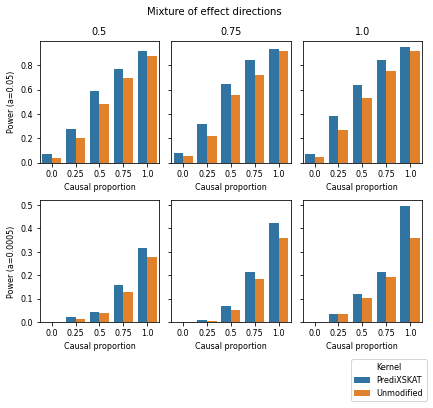

In [33]:
df = pd.read_csv('/rawdata/fig5_rawdata.csv')
df.columns=['Causal proportion', 'Effect direction mixture', 'A', 'B']
#df = df[['Causal proportion', 'Effect direction mixture', 'A', 'F']]
df = df.loc[df['Effect direction mixture']>=0.5]
df.columns=['Causal proportion', 'Effect direction mixture', 'Unmodified', 'PrediXSKAT',]
noefp = df.melt(id_vars=['Causal proportion', 'Effect direction mixture'], var_name='kernel', value_name='pval')

noef_power1 = noefp.groupby(['Causal proportion', 'Effect direction mixture', 'kernel']).apply(power, alpha=0.05).reset_index()
noef_power2 = noefp.groupby(['Causal proportion', 'Effect direction mixture', 'kernel']).apply(power, alpha=0.0005).reset_index()

dataframes = [noef_power1, noef_power2]
col_vals = noef_power1['Effect direction mixture'].unique() 
n_rows, n_cols = len(dataframes), len(col_vals)
row_labels = ['Power (a=0.05)', 'Power (a=0.0005)'] 
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6,5),
    sharey='row')

for row, df in enumerate(dataframes):
    for col, col_val in enumerate(col_vals):
        ax = axes[row, col]
        subset = df[df['Effect direction mixture'] == col_val]
        sns.barplot(data=subset, x='Causal proportion', y=0, hue='kernel', ax=ax)
        if row == 0:
            ax.set_title(col_val)
        ax.set_ylabel(row_labels[row] if col == 0 else '')
        ax.get_legend().remove()

fig.suptitle('Mixture of effect directions', fontsize=10)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Kernel', loc='lower right', bbox_to_anchor=(1, -0.125))

plt.tight_layout();
fig.savefig("fig5.pdf", format="pdf", bbox_inches="tight");
